# 18: Can Experience Change the Material?

A tiny state extension: EMPTY, OCCUPIED-NORMAL, OCCUPIED-MODIFIED. The supported result is V7, not V10.


In [1]:
from pathlib import Path
import json
import math
import random
import sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams, CrystalState, neighbors, hex_distance, hex_capacity,
    axial_to_xy, logistic, local_exposure_angle, initial_state, clone_state,
    morphology_hash, frontier, attachment_probability, advance_one_step,
    run_crystal, cell_keyed_uniform,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

NOTEBOOK_PROFILE = "quick"
RUN_CANONICAL = False

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def audit(expected, observed, source):
    return {
        "source": source,
        "expected": expected,
        "observed": observed,
        "matches": {k: observed.get(k) == v for k, v in expected.items()},
    }

def plot_cells(cells, title, ax=None, color="tab:blue"):
    ax = ax or plt.gca()
    pts = np.array([axial_to_xy(c) for c in cells]) if cells else np.empty((0, 2))
    if len(pts):
        ax.scatter(pts[:, 0], pts[:, 1], marker="h", s=42, c=color, alpha=0.9)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


In [2]:
EMPTY, NORMAL, MODIFIED = 0, 1, 2
cells = {(0, 0): NORMAL, (1, 0): MODIFIED}
def modified_frontier_contacts(cells):
    occupied = set(cells)
    contacts = 0
    for cell in occupied:
        if cells[cell] == MODIFIED:
            contacts += sum(nb not in occupied for nb in neighbors(cell))
    return contacts
{"modified_state_persists": cells[(1,0)] == MODIFIED, "frontier_contacts": modified_frontier_contacts(cells)}


{'modified_state_persists': True, 'frontier_contacts': 5}

## Local causal chain


In [3]:
occupied = set(cells)
candidate = (2, 0)
base_p = attachment_probability(candidate, occupied, 0.4)
modified_neighbor_bonus = 0.18 if any(cells.get(nb) == MODIFIED for nb in neighbors(candidate)) else 0.0
changed_p = min(1.0, base_p + modified_neighbor_bonus)
u = 0.5 * (base_p + changed_p)
{"base_probability": base_p, "modified_probability": changed_p, "same_random_value": u, "decision_flips": base_p <= u < changed_p}


{'base_probability': 0.4117464954881444,
 'modified_probability': 0.5917464954881444,
 'same_random_value': 0.5017464954881444,
 'decision_flips': True}

## Canonical V7 audit and later failed broad claims


In [4]:
v7 = load_json("research/digital-life/ch18-persistent-material-state-v7/stage-02-integrated-causal-lifetime.json")
verdict7 = load_json("research/digital-life/ch18-persistent-material-state-v7/stage-04-verdict.json")
v8 = load_json("research/digital-life/ch18-persistent-material-state-v8/stage-04-verdict.json")
v9 = load_json("research/digital-life/ch18-persistent-material-state-v9/stage-04-verdict.json")
v10 = load_json("research/digital-life/ch18-persistent-material-state-v10/stage-04-efficiency-verdict.json")
policies = ["interior_biased", "random_matched", "surface_biased"]
observed = {
    "access": [round(v7["summary"][p]["access_fraction_auc"]["mean"], 3) for p in policies],
    "leverage": [round(v7["summary"][p]["probability_leverage_auc"]["mean"], 2) for p in policies],
    "flips": [round(v7["summary"][p]["total_realized_flips"]["mean"], 2) for p in policies],
    "v7_status": verdict7["status"],
    "v8_status": v8["status"],
    "v9_status": v9["status"],
    "v10_status": v10["status"],
}
EXPECTED = {"access": [0.515, 0.847, 1.293], "leverage": [3.87, 7.33, 12.26], "flips": [4.06, 7.52, 12.39], "v7_status": "SUPPORTED", "v8_status": "FAILED", "v9_status": "FAILED", "v10_status": "FAILED"}
audit(EXPECTED, observed, "canonical report artifact")


{'source': 'canonical report artifact',
 'expected': {'access': [0.515, 0.847, 1.293],
  'leverage': [3.87, 7.33, 12.26],
  'flips': [4.06, 7.52, 12.39],
  'v7_status': 'SUPPORTED',
  'v8_status': 'FAILED',
  'v9_status': 'FAILED',
  'v10_status': 'FAILED'},
 'observed': {'access': [0.515, 0.847, 1.293],
  'leverage': [3.87, 7.33, 12.26],
  'flips': [4.06, 7.52, 12.39],
  'v7_status': 'SUPPORTED',
  'v8_status': 'FAILED',
  'v9_status': 'FAILED',
  'v10_status': 'FAILED'},
 'matches': {'access': True,
  'leverage': True,
  'flips': True,
  'v7_status': True,
  'v8_status': True,
  'v9_status': True,
  'v10_status': True}}

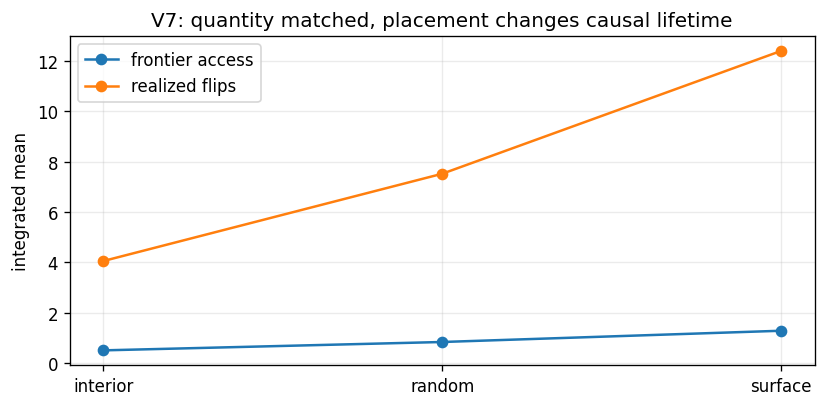

In [5]:
x = np.arange(3); labels = ["interior", "random", "surface"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(labels, observed["access"], marker="o", label="frontier access")
ax.plot(labels, observed["flips"], marker="o", label="realized flips")
ax.set(title="V7: quantity matched, placement changes causal lifetime", ylabel="integrated mean")
ax.legend(); ax.grid(alpha=0.25); fig.tight_layout()
fig.savefig(FIG_DIR / "ch18-v7-placement-audit.png", bbox_inches="tight")
plt.show()


## Bounded conclusion

Modified material can persist, but persistence is not causal accessibility. V7 supports that, with propagated quantity held fixed, placement changes how long and strongly historical material remains causally available. V8-V10 remain failed broad claims. Storage is cheap; access is scarce. Do not call it memory.

## Provenance

Book chapter: `content/books/digital-life/18-persistent-material-state/index.md`

Research scripts: `ch18_digital_crystal_persistent_material_state_v1.py` through `v10.py`

Canonical artifacts: `research/digital-life/ch18-persistent-material-state-v1/` through `v10/`, promoted result from `v7/`

Execution mode: quick-recomputed + canonical-artifact-audit
